# Training phase

## - introduction: setting GPU based training and showing our data

In [1]:
import pandas as pd
import os
import librosa as librs
import numpy as np
import IPython.display as ipd
import matplotlib.pyplot as plt
import os
import wave
import matplotlib.pylab as pyl
import soundfile as sf
import tensorflow as tf
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, Activation, BatchNormalization, SpatialDropout1D, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score

In [2]:
# GPU configuration

import warnings
warnings.filterwarnings("ignore")

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Num GPUs Available:  0


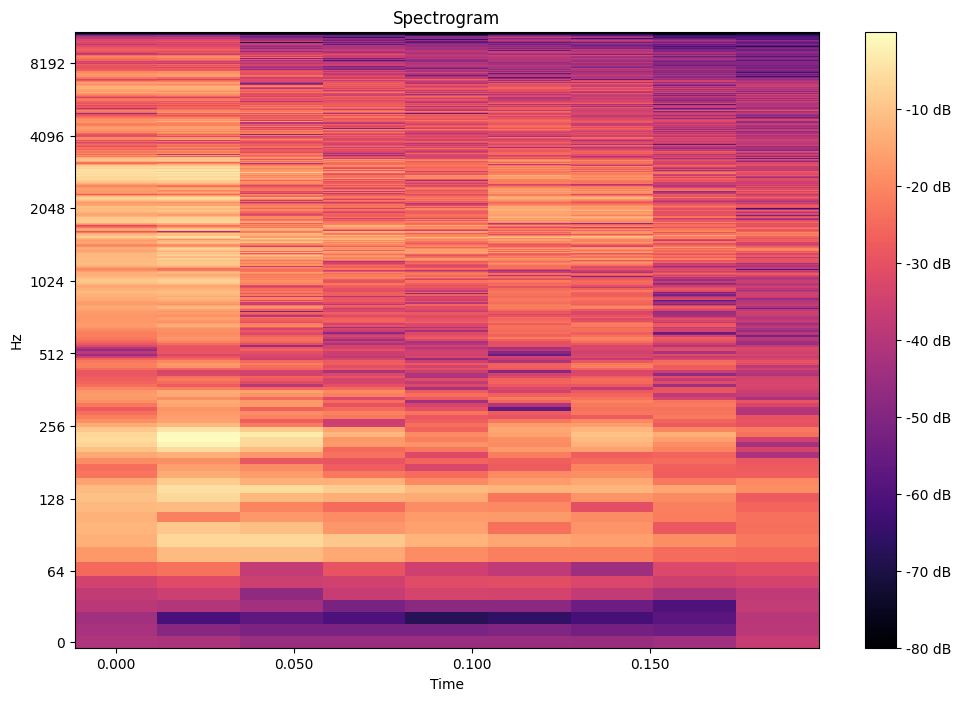

In [3]:
# Showing spectrogram

# Load the audio file
input_wav = "AudioArchive/DatasetSplittedAugmented/augmented_a_split_15_2.wav"
y, sr = librs.load(input_wav)

# Compute the spectrogram
D = librs.amplitude_to_db(np.abs(librs.stft(y)), ref=np.max)

# Plot the spectrogram
plt.figure(figsize=(12, 8))
librs.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.savefig('results/spectrogram.png')
plt.show()

#print('sr: ',sr)

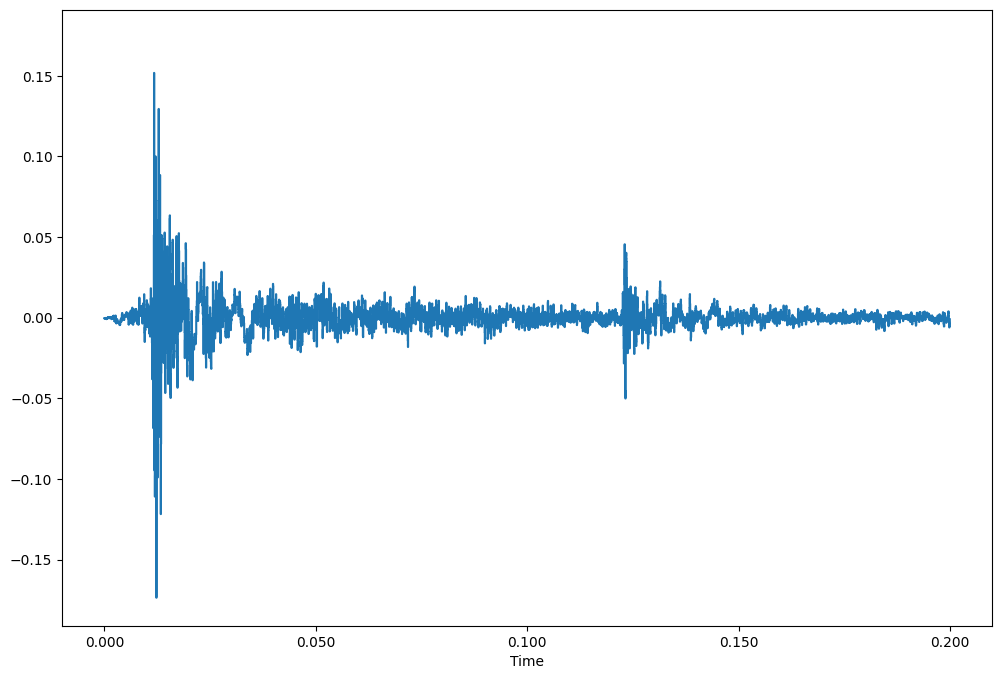

In [4]:
# Showing a splitted augmented wave of a click

file_name='AudioArchive/DatasetSplittedAugmented/augmented_a_split_15_2.wav'
audio_data, sampling_rate = librs.load(file_name)
plt.figure(figsize=(12, 8))
librs.display.waveshow(audio_data,sr=sampling_rate)
plt.savefig('results/single_audio_signal.png')

In [5]:
# Showing the fist lines of our csv file with the list of all augmented clicks
metadata = pd.read_csv('augmented_audio_list.csv')
metadata.head()

,slice_file_name,fold,classID,class
0,augmented_0_split_10_0.wav,16,1,0
1,augmented_0_split_10_1.wav,16,1,0
2,augmented_0_split_10_2.wav,16,1,0
3,augmented_0_split_11_0.wav,16,1,0
4,augmented_0_split_11_1.wav,16,1,0


In [6]:
# Showing how many click we have for each key

metadata['class'].value_counts()

class
0    75
1    75
k    75
l    75
m    75
n    75
o    75
p    75
q    75
r    75
s    75
t    75
u    75
v    75
w    75
x    75
y    75
j    75
i    75
h    75
8    75
2    75
3    75
4    75
5    75
6    75
7    75
9    75
g    75
a    75
b    75
c    75
d    75
e    75
f    75
z    75
Name: count, dtype: int64

In [7]:
# Showing how a mfcc is represented

mfccs = librs.feature.mfcc(y = audio_data, sr = sampling_rate, n_mfcc = 36)
display(mfccs)

array([[-2.22869812e+02, -2.01246155e+02, -2.78569641e+02,
        -3.20857574e+02, -3.37647766e+02, -3.09307007e+02,
        -3.17063446e+02, -3.84731842e+02, -4.19910583e+02],
       [ 2.57362804e+01,  3.33639336e+01,  3.86262589e+01,
         3.08847694e+01,  3.30935364e+01,  3.73119659e+01,
         4.96984329e+01,  4.88059616e+01,  4.54792175e+01],
       [-5.20856171e+01, -4.91716347e+01, -4.14670105e+01,
        -4.16805115e+01, -4.81988449e+01, -5.78687515e+01,
        -5.12578583e+01, -3.88524551e+01, -4.17360802e+01],
       [ 5.62067509e+00,  9.76285839e+00,  2.18411369e+01,
         2.23184738e+01,  1.91542931e+01,  1.95107422e+01,
         2.18217735e+01,  2.50475426e+01,  2.46488476e+01],
       [ 8.20838809e-02,  1.98490071e+00,  4.92959642e+00,
         5.17333317e+00,  5.01364231e+00,  1.03176260e+01,
         1.57595673e+01,  1.94914246e+01,  1.45429897e+01],
       [ 9.32247066e+00,  1.50954571e+01,  3.26315155e+01,
         3.85080185e+01,  3.48250313e+01,  1.136342

<br>
<br>
<br>


## - Feature extraction

In [8]:
def features_extractor(file):
    audio, sample_rate = librs.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)

    return mfccs_scaled_features

In [9]:
extracted_features=[]
audio_dataset_path='AudioArchive/DatasetSplittedAugmented'

for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_dataset_path),str(row["slice_file_name"]))
    #print(file_name)
    final_class_labels = row["class"]
    data = features_extractor(file_name)
    extracted_features.append([data,final_class_labels])

2700it [00:25, 105.20it/s]


In [10]:
extracted_features_df = pd.DataFrame(extracted_features,columns=['feature','class'])
extracted_features_df.head(100)

,feature,class
0,"[-317.6592, 63.804462, -34.250916, 0.24203904,...",0
1,"[-317.63086, 63.968193, -34.222992, 0.3969476,...",0
2,"[-317.9547, 64.28341, -34.648678, 0.6470043, -...",0
3,"[-308.62048, 62.038284, -33.398952, 1.4341321,...",0
4,"[-308.72168, 62.193394, -33.52398, 1.5273166, ...",0
...,...,...
95,"[-329.7806, 40.628597, -47.784702, 22.741827, ...",1
96,"[-304.36288, 39.929058, -46.92692, 23.703453, ...",1
97,"[-304.6344, 40.264935, -47.17001, 23.939627, 7...",1
98,"[-304.95032, 40.6949, -47.59933, 24.350323, 6....",1


In [11]:
X = np.array(extracted_features_df['feature'].tolist())
y = np.array(extracted_features_df['class'].tolist())

labelencoder = LabelEncoder()
y = to_categorical(labelencoder.fit_transform(y))

In [12]:
# Save the labelencoder
import pickle

with open('labelencoder.pkl', 'wb') as f:
    pickle.dump(labelencoder, f)

<br>
<br>
<br>


## - Build TCN: define dataset variables, build TCN model 

In [13]:
import tensorflow as tf

# Define dataset variables for split in train and test
test_size=0.2
shuffle=True
stratify=None
random_state=3
# Define input shape and number of classes
input_dim = 1
input_shape = (input_dim,)
num_classes = 36
kernel_size = 3
num_filters = 128
num_layers = 4
dropout_rate = 0.2
# Define a custom learning rate
learning_rate = 0.001
# Train the model
batch_size = 32
epochs = 500

In [14]:
#X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, shuffle=shuffle, stratify=stratify)

num_labels = y.shape[1]
num_labels

36

In [15]:
def build_tcn(input_shape, num_classes, num_filters=num_filters, kernel_size=kernel_size, num_layers=num_layers, dropout_rate=0.2):
    inputs = Input(shape=input_shape)

    # Expand dimensions to match 3D convolutional input
    x = tf.expand_dims(inputs, axis=-1)

    for i in range(num_layers):
        dilation_rate = 2 ** i
        x = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = SpatialDropout1D(rate=dropout_rate)(x)

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

In [16]:
# Build TCN model
tcn_model = build_tcn(input_shape, num_classes)

# Define an optimizer with the desired learning rate
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# Compile the model
tcn_model.compile(optimizer=my_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
tcn_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 tf.expand_dims (TFOpLambda)  (None, 1, 1)             0         
                                                                 
 conv1d (Conv1D)             (None, 1, 128)            512       
                                                                 
 batch_normalization (BatchN  (None, 1, 128)           512       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 1, 128)            0         
                                                                 
 spatial_dropout1d (SpatialD  (None, 1, 128)           0         
 ropout1D)                                                   

<br>
<br>
<br>


## - Training and evaluation 

In [17]:
from tensorflow.keras.utils import plot_model

# Plot the TCN model and save it as an image file
plot_model(tcn_model, to_file='Results/tcn_model.png', show_shapes=True, show_layer_names=True)
print("TCN model architecture saved as 'tcn_model.png'")

TCN model architecture saved as 'tcn_model.png'


In [18]:
with tf.device('/GPU:0'):
    # Code to run on GPU
    # Train the model with augmented data
    history = tcn_model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))    

Epoch 1/500
68/68 [==============================] - 12s 100ms/step - loss: 3.6015 - accuracy: 0.0380 - val_loss: 3.9669 - val_accuracy: 0.0333
Epoch 2/500
68/68 [==============================] - 5s 76ms/step - loss: 3.3725 - accuracy: 0.0606 - val_loss: 4.4183 - val_accuracy: 0.0296
Epoch 3/500
68/68 [==============================] - 6s 90ms/step - loss: 3.0164 - accuracy: 0.1477 - val_loss: 3.4001 - val_accuracy: 0.0685
Epoch 4/500
68/68 [==============================] - 5s 67ms/step - loss: 2.6550 - accuracy: 0.2653 - val_loss: 2.3713 - val_accuracy: 0.3315
Epoch 5/500
68/68 [==============================] - 6s 86ms/step - loss: 2.3183 - accuracy: 0.3542 - val_loss: 1.8821 - val_accuracy: 0.5537
Epoch 6/500
68/68 [==============================] - 7s 97ms/step - loss: 1.9996 - accuracy: 0.4597 - val_loss: 1.6785 - val_accuracy: 0.6185
Epoch 7/500
68/68 [==============================] - 6s 96ms/step - loss: 1.7437 - accuracy: 0.5472 - val_loss: 1.5029 - val_accuracy: 0.6519
Epoc

Epoch 336/500
68/68 [==============================] - 1s 19ms/step - loss: 0.0026 - accuracy: 0.9995 - val_loss: 1.3019e-04 - val_accuracy: 1.0000
Epoch 337/500
68/68 [==============================] - 1s 17ms/step - loss: 0.0034 - accuracy: 0.9995 - val_loss: 0.0015 - val_accuracy: 1.0000
Epoch 338/500
68/68 [==============================] - 1s 17ms/step - loss: 0.0044 - accuracy: 0.9995 - val_loss: 3.7169e-05 - val_accuracy: 1.0000
Epoch 339/500
68/68 [==============================] - 1s 17ms/step - loss: 0.0063 - accuracy: 0.9986 - val_loss: 0.0013 - val_accuracy: 1.0000
Epoch 340/500
68/68 [==============================] - 1s 17ms/step - loss: 0.0045 - accuracy: 1.0000 - val_loss: 7.1778e-05 - val_accuracy: 1.0000
Epoch 341/500
68/68 [==============================] - 1s 17ms/step - loss: 0.0038 - accuracy: 0.9995 - val_loss: 1.3042e-04 - val_accuracy: 1.0000
Epoch 342/500
68/68 [==============================] - 1s 17ms/step - loss: 0.0041 - accuracy: 0.9995 - val_loss: 0.0017

Epoch 392/500
68/68 [==============================] - 1s 18ms/step - loss: 0.0018 - accuracy: 0.9995 - val_loss: 7.2193e-05 - val_accuracy: 1.0000
Epoch 393/500
68/68 [==============================] - 1s 19ms/step - loss: 0.0013 - accuracy: 1.0000 - val_loss: 3.9231e-04 - val_accuracy: 1.0000
Epoch 394/500
68/68 [==============================] - 1s 17ms/step - loss: 0.0029 - accuracy: 0.9986 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 395/500
68/68 [==============================] - 1s 18ms/step - loss: 0.0027 - accuracy: 0.9995 - val_loss: 0.0015 - val_accuracy: 1.0000
Epoch 396/500
68/68 [==============================] - 1s 19ms/step - loss: 0.0031 - accuracy: 0.9991 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 397/500
68/68 [==============================] - 1s 19ms/step - loss: 0.0050 - accuracy: 0.9986 - val_loss: 0.0041 - val_accuracy: 0.9981
Epoch 398/500
68/68 [==============================] - 1s 19ms/step - loss: 0.0042 - accuracy: 0.9981 - val_loss: 0.0176 - val_a

68/68 [==============================] - 1s 18ms/step - loss: 0.0020 - accuracy: 1.0000 - val_loss: 2.3913e-04 - val_accuracy: 1.0000
Epoch 449/500
68/68 [==============================] - 1s 19ms/step - loss: 0.0031 - accuracy: 0.9991 - val_loss: 2.2176e-04 - val_accuracy: 1.0000
Epoch 450/500
68/68 [==============================] - 1s 18ms/step - loss: 0.0019 - accuracy: 1.0000 - val_loss: 3.8679e-04 - val_accuracy: 1.0000
Epoch 451/500
68/68 [==============================] - 1s 18ms/step - loss: 0.0049 - accuracy: 0.9986 - val_loss: 5.7165e-05 - val_accuracy: 1.0000
Epoch 452/500
68/68 [==============================] - 1s 22ms/step - loss: 0.0034 - accuracy: 0.9995 - val_loss: 3.9371e-04 - val_accuracy: 1.0000
Epoch 453/500
68/68 [==============================] - 2s 29ms/step - loss: 0.0068 - accuracy: 0.9972 - val_loss: 1.3796e-05 - val_accuracy: 1.0000
Epoch 454/500
68/68 [==============================] - 1s 19ms/step - loss: 0.0035 - accuracy: 0.9991 - val_loss: 7.2741e-05 -

In [19]:
# Save the model
from tensorflow.keras.models import save_model

save_model(tcn_model, 'tcn_model_new.h5')  # Save in format h5

In [20]:
# Evaluate the model on the training set
train_loss, train_accuracy = tcn_model.evaluate(X_train, y_train)
print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy*100:.4f}%")

68/68 [==============================] - 2s 24ms/step - loss: 2.0806e-05 - accuracy: 1.0000
Train Loss: 0.0000, Train Accuracy: 100.0000%


In [21]:
# Evaluate the model
test_loss, test_accuracy = tcn_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy*100:.4f}%")

17/17 [==============================] - 0s 22ms/step - loss: 1.0230e-04 - accuracy: 1.0000
Test Loss: 0.0001, Test Accuracy: 100.0000%


<br>
<br>
<br>


## - Prediction and graphic demonstration of the performance  

In [22]:
# Get predictions for samples 0 to lenght of X_test
#start_index = 0
start_index = 20
#end_index = len(X_test)
end_index = 56
predictions = tcn_model.predict(X_test[start_index:end_index])
true_labels = np.argmax(y_test[start_index:end_index], axis=1)  # Assuming y_test is one-hot encoded
predicted_labels = np.argmax(predictions, axis=1)

2/2 [==============================] - 0s 11ms/step


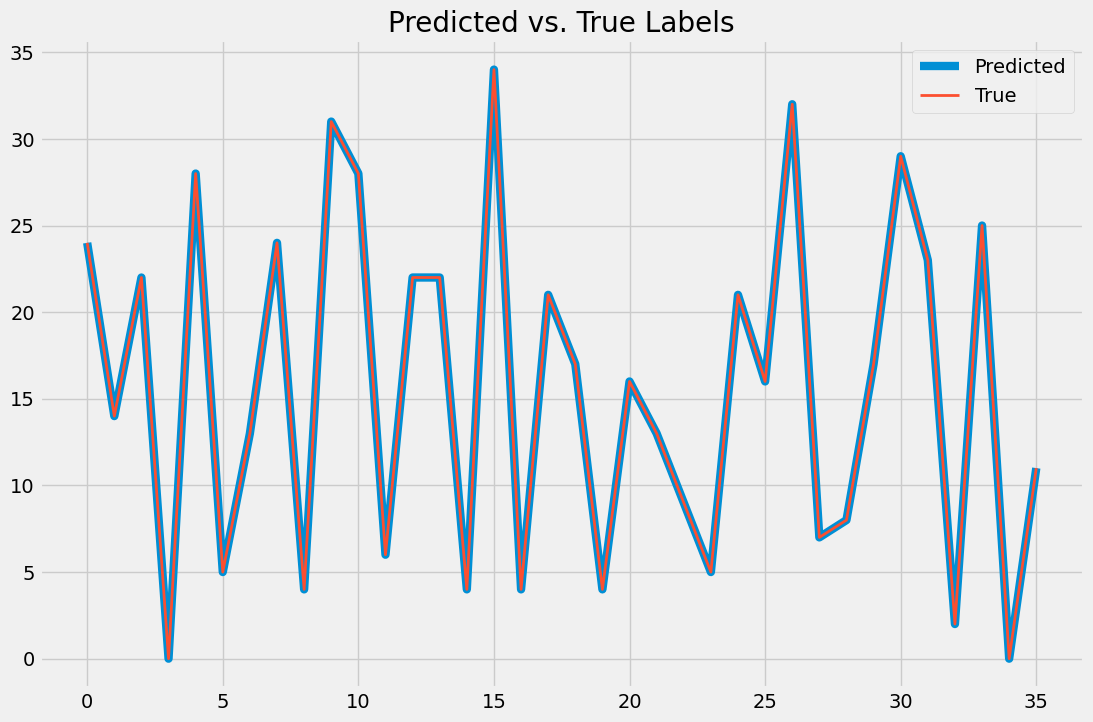

In [23]:
# Create a bar plot to visualize predicted vs. true labels
plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 8))
plt.plot(predicted_labels, label='Predicted', linewidth = '6.0')
plt.plot(true_labels, label='True', linewidth = '2.0')
plt.title('Predicted vs. True Labels')
plt.legend()
plt.savefig('Results/inference_curve_zoom.png')
plt.show()

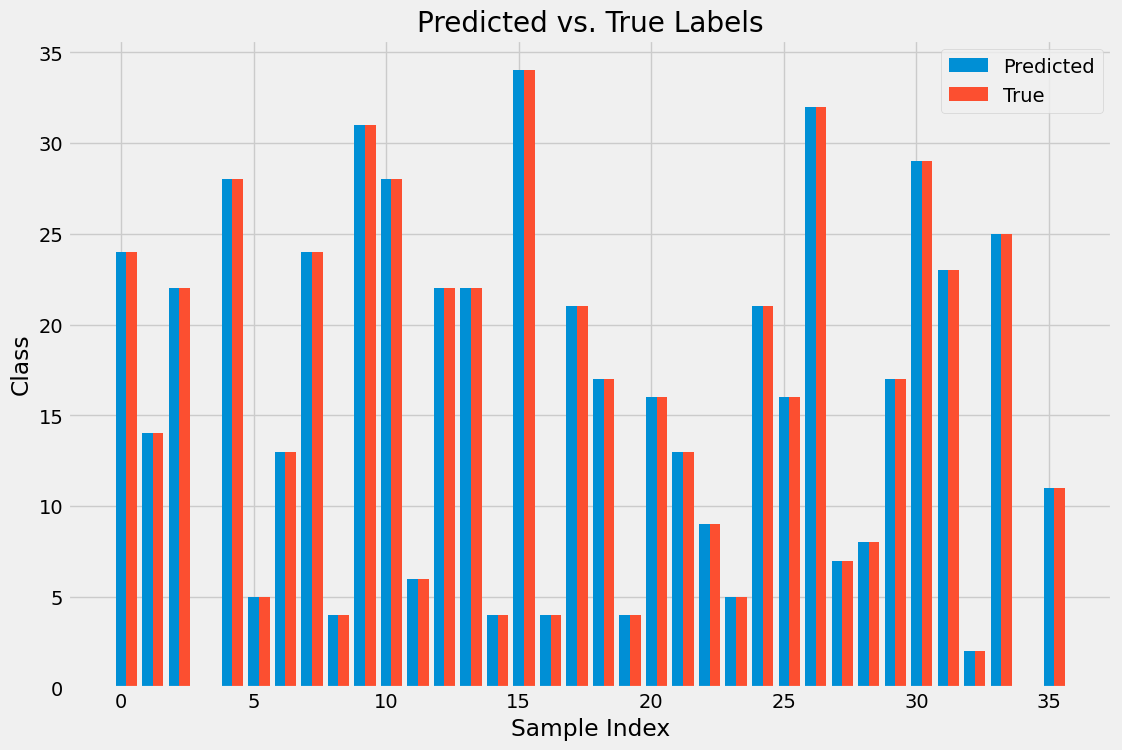

In [24]:
# Create a bar plot to visualize predicted vs. true labels
plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 8))
plt.bar(np.arange(len(predicted_labels)), predicted_labels, width=0.4, label='Predicted', align='center')
plt.bar(np.arange(len(true_labels)) + 0.4, true_labels, width=0.4, label='True', align='center')
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.title('Predicted vs. True Labels')
plt.legend()
plt.savefig('Results/inference_bar_zoom.png')
plt.show()

In [25]:
# Make predictions using the model
predictions = tcn_model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

17/17 [==============================] - 0s 19ms/step


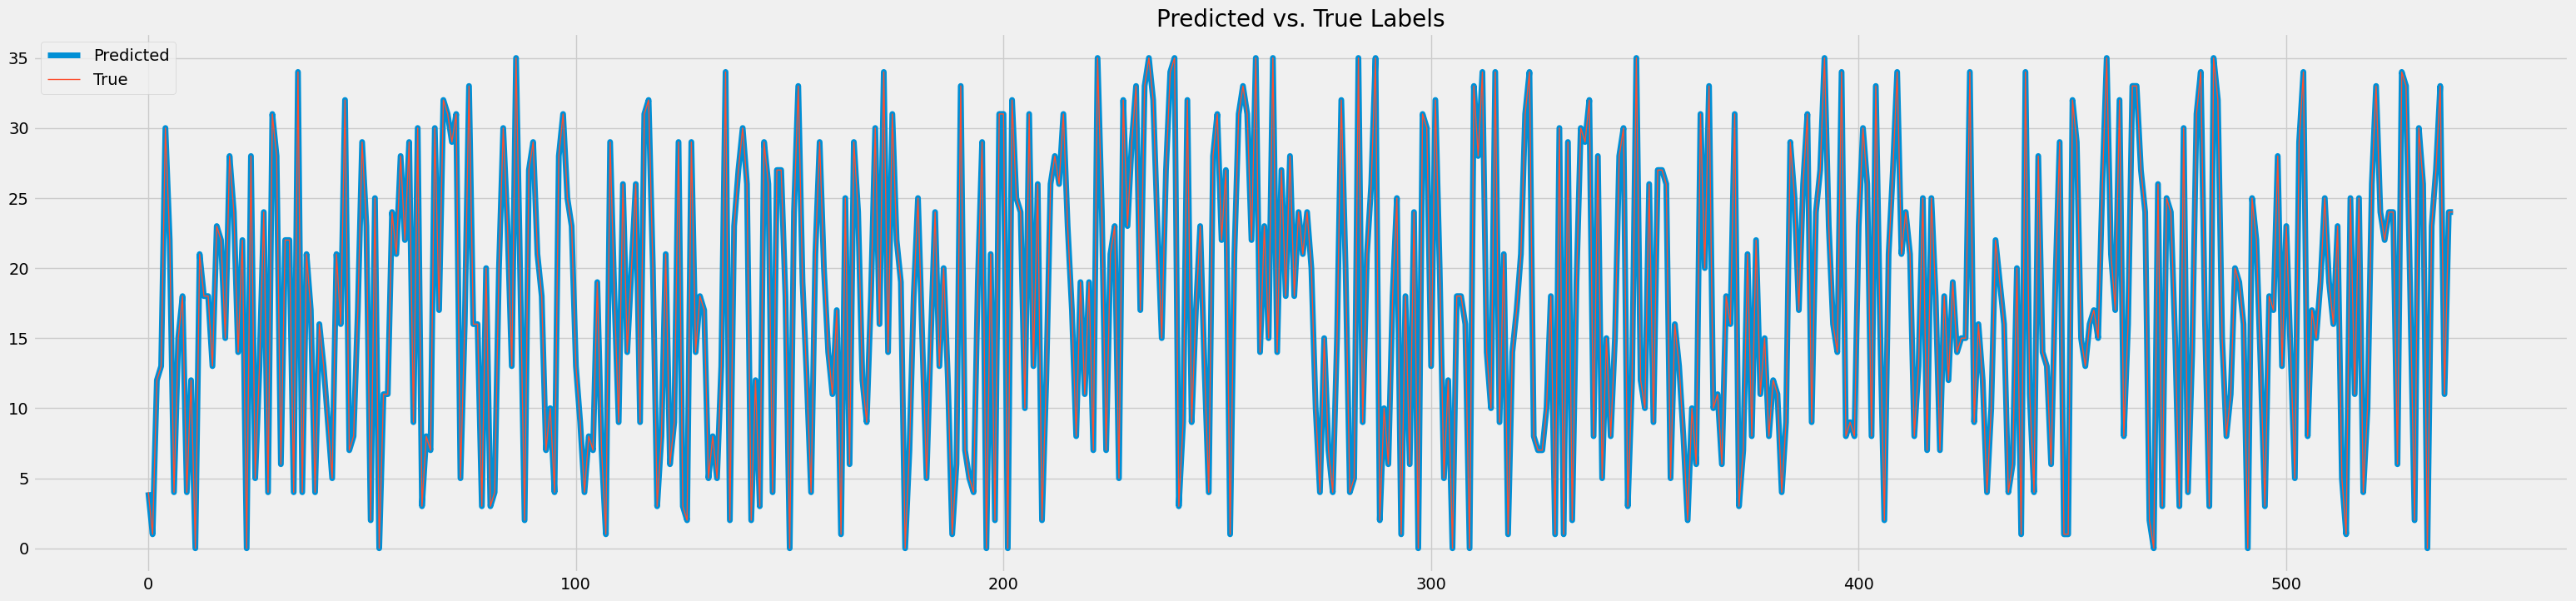

In [26]:
# Create a bar plot to visualize predicted vs. true labels
plt.style.use("fivethirtyeight")
plt.figure(figsize=(35, 8))
plt.plot(predicted_labels, label='Predicted', linewidth = '5.0')
plt.plot(true_labels, label='True', linewidth = '1.0')
plt.title('Predicted vs. True Labels')
plt.legend()
plt.savefig('Results/inference_curve.png')
plt.show()

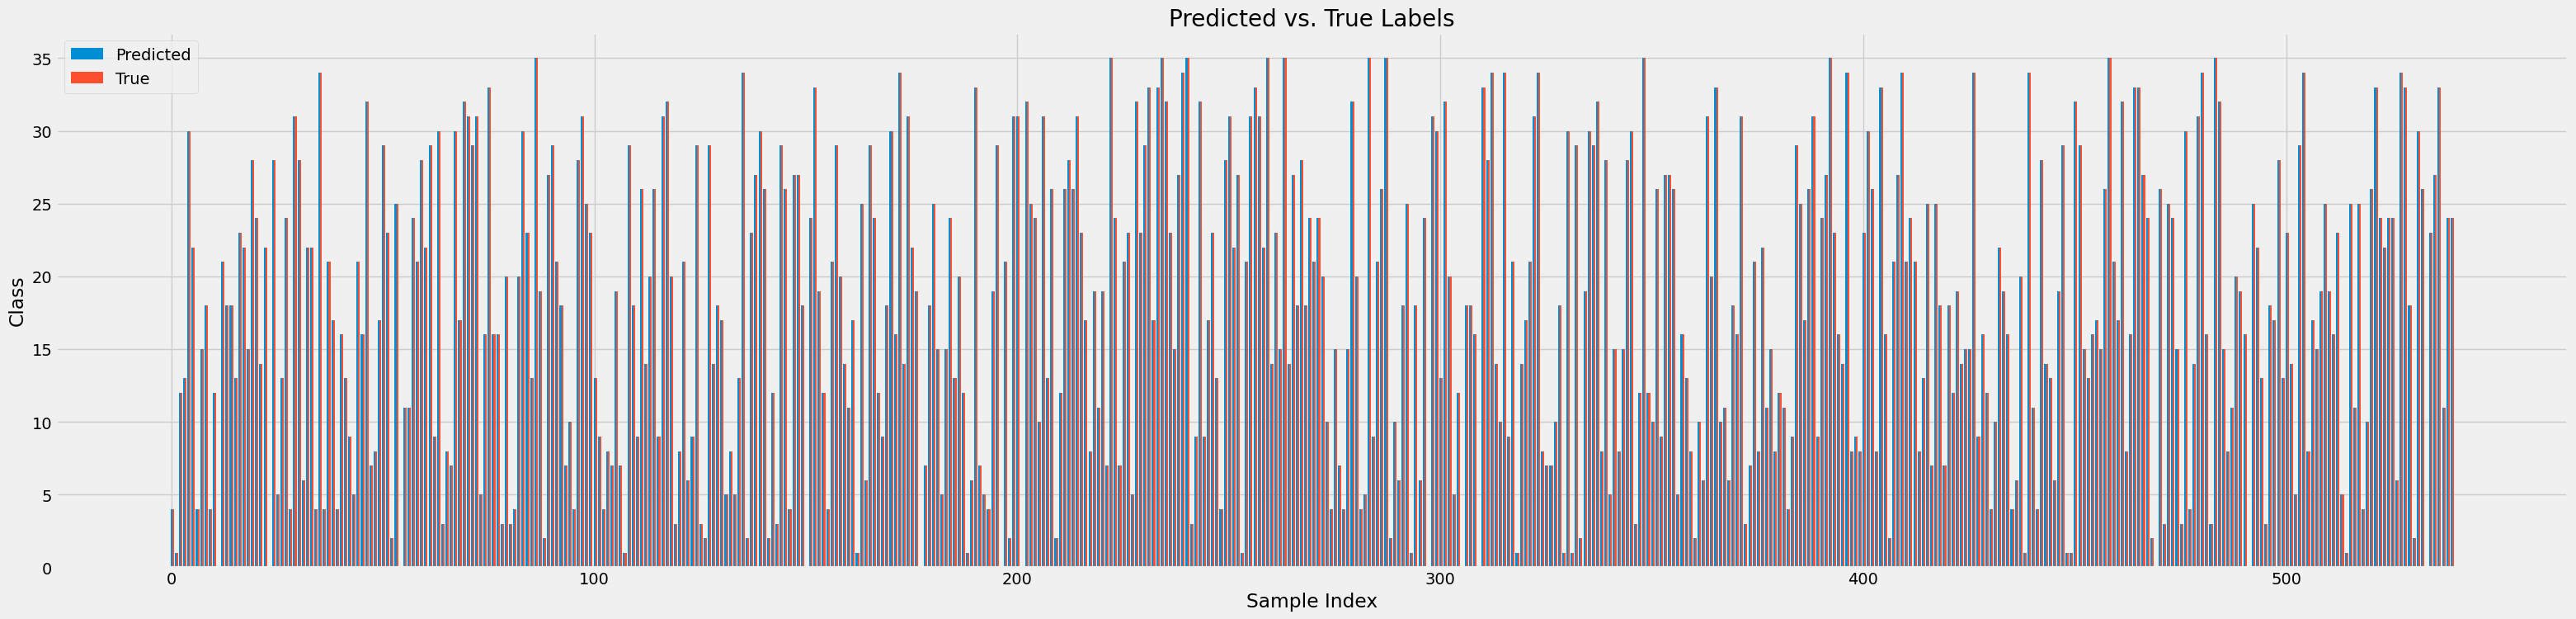

In [27]:
# Create a bar plot to visualize predicted vs. true labels
plt.style.use("fivethirtyeight")
plt.figure(figsize=(35, 8))
plt.bar(np.arange(len(predicted_labels)), predicted_labels, width=0.4, label='Predicted', align='center')
plt.bar(np.arange(len(true_labels)) + 0.4, true_labels, width=0.4, label='True', align='center')
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.title('Predicted vs. True Labels')
plt.legend()
plt.savefig('Results/inference_bar.png')
plt.show()

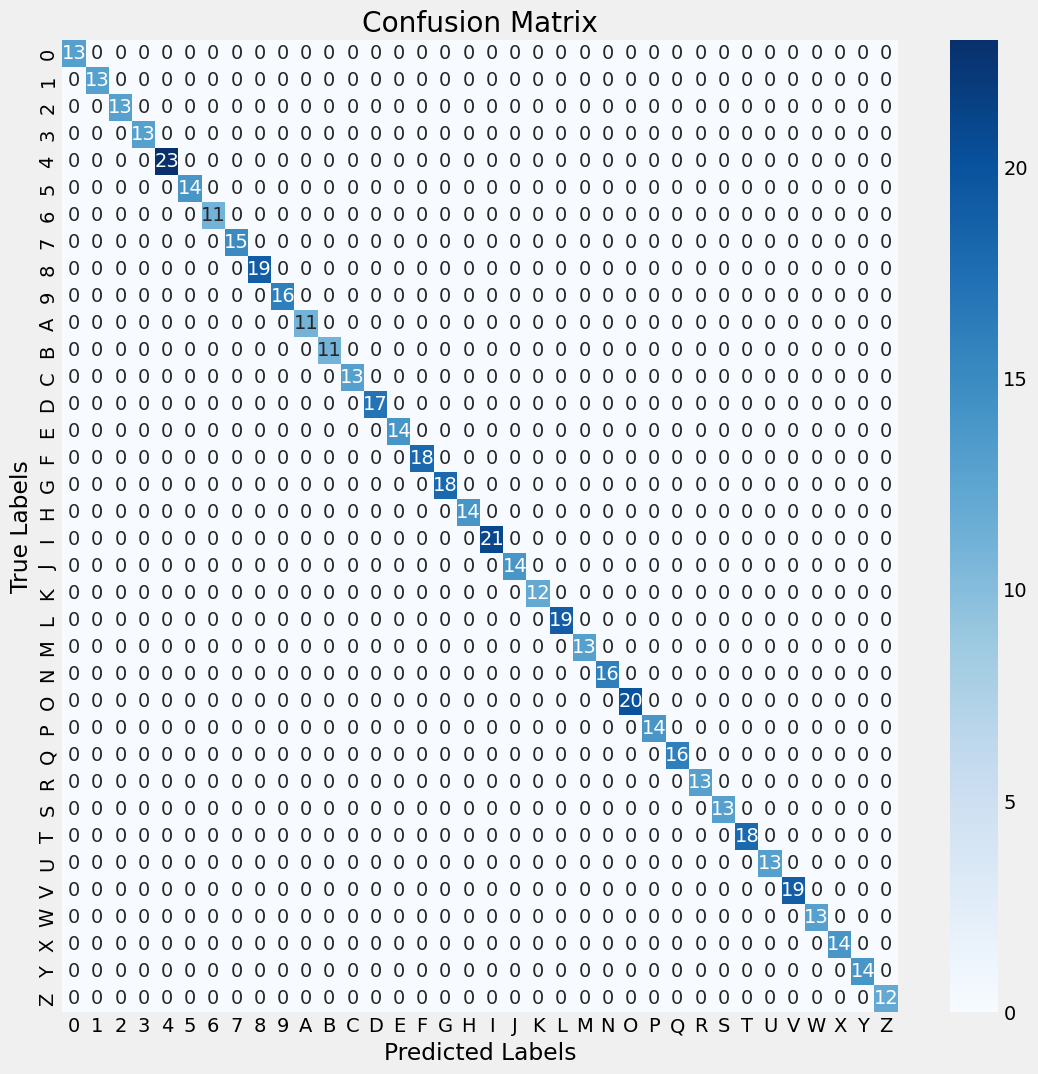

In [28]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
# Replace 'classes' with your actual class labels
#classes = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36']
classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

# Plot the confusion matrix
plt.style.use("fivethirtyeight")
y_true = true_labels
y_pred = predicted_labels
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('Results/confusion_matrix.png')
plt.show()

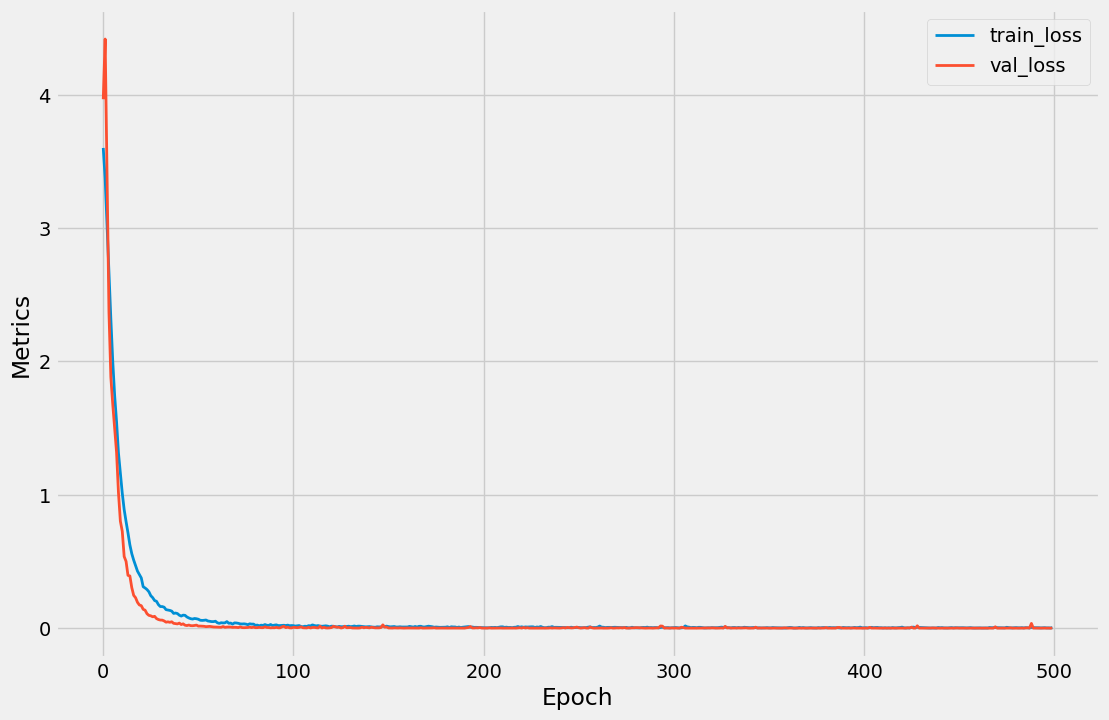

In [29]:
# Plot training history
plt.style.use("fivethirtyeight")
plt.figure(figsize=(12, 8))
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.plot(history.history['loss'], label='train_loss', linewidth = '2.0')
plt.plot(history.history['val_loss'], label='val_loss', linewidth = '2.0')
plt.legend(loc = 'best', fontsize=14)
plt.savefig('Results/loss.png')
plt.show()

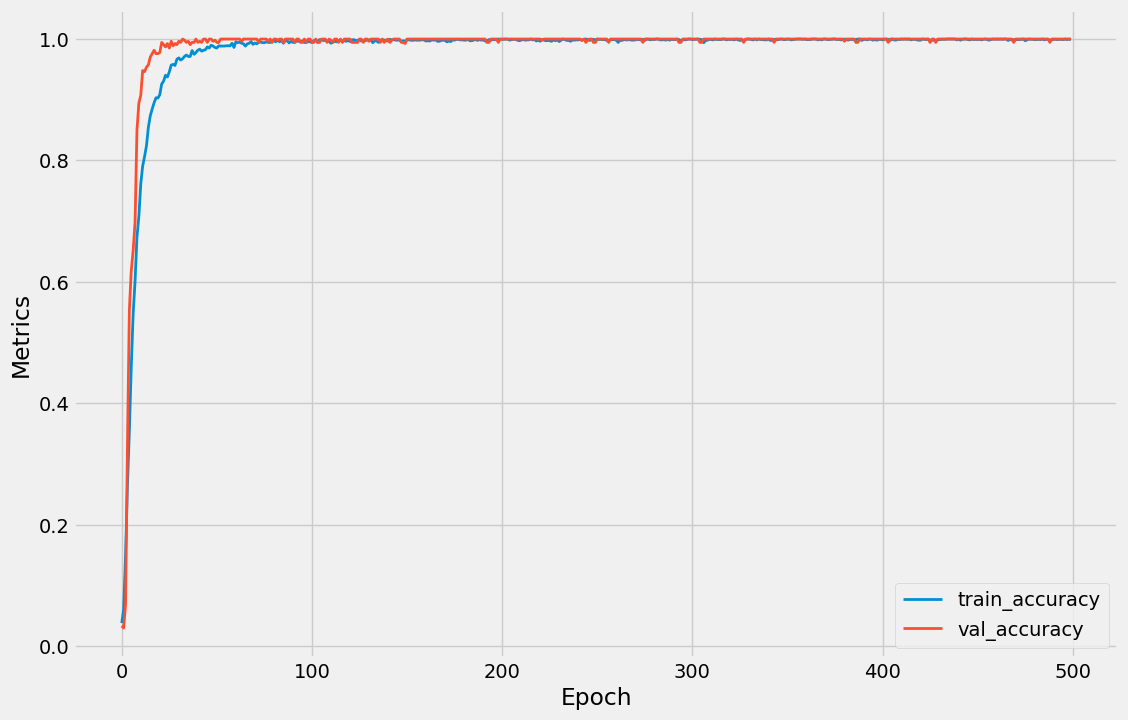

In [30]:
# Plot training history
plt.figure(figsize=(12, 8))
plt.plot(history.history['accuracy'], label='train_accuracy', linewidth = '2.0')
plt.plot(history.history['val_accuracy'], label='val_accuracy', linewidth = '2.0')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.legend()
plt.savefig('Results/accuracy.png')
plt.show()

In [31]:
# Calculate and print classification report
report = classification_report(true_labels, predicted_labels, target_names=classes)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        23
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        11
           7       1.00      1.00      1.00        15
           8       1.00      1.00      1.00        19
           9       1.00      1.00      1.00        16
           A       1.00      1.00      1.00        11
           B       1.00      1.00      1.00        11
           C       1.00      1.00      1.00        13
           D       1.00      1.00      1.00        17
           E       1.00      1.00      1.00        14
           F       1.00      1.00      1.00        18
           G       1.00      1.00      1.00        18
    

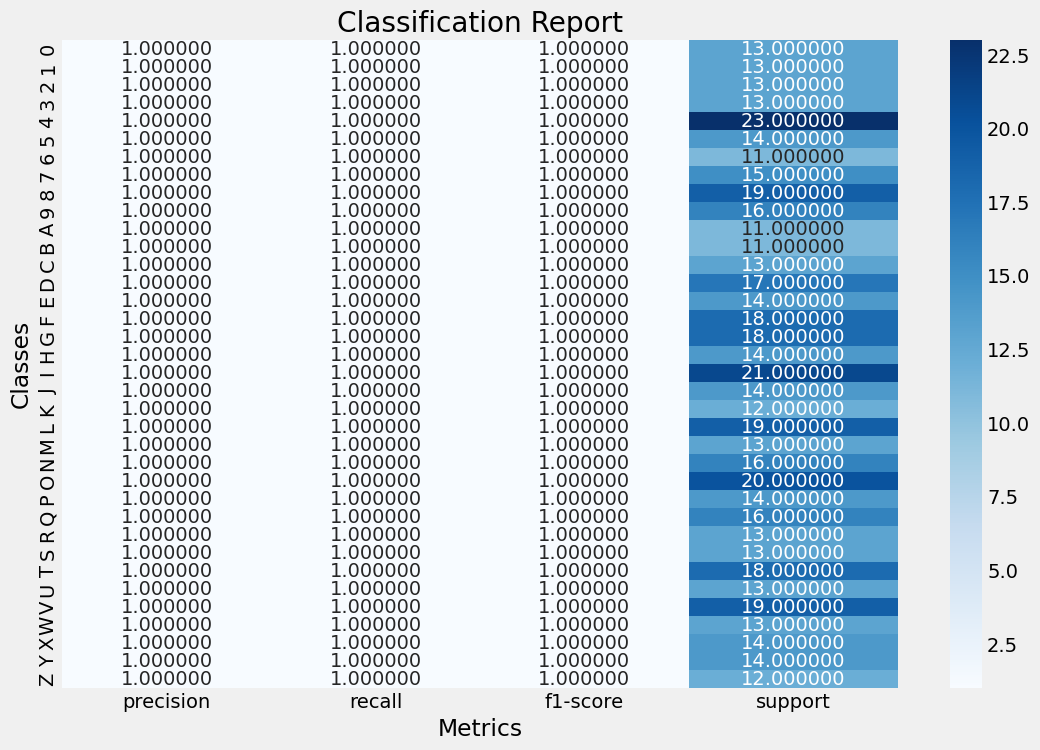

In [32]:
# Create a heatmap-style plot for classification report metrics
def plot_classification_report(report):
    report_data = []
    lines = report.split('\n')
    for line in lines[2:-5]:
        row = line.split()
        report_data.append(row)

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(np.array(report_data)[:, 1:].astype(float), annot=True, cmap='Blues', fmt='f', xticklabels=['precision', 'recall', 'f1-score', 'support'], yticklabels=classes)
    #sns.heatmap(np.array(report_data)[:, 1:].astype(float), annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=np.array(report_data)[:, 0])
    plt.xlabel("Metrics")
    plt.ylabel("Classes")
    plt.title("Classification Report")
    plt.savefig('Results/classification.png')
    plt.show()

# Plot the classification report
plot_classification_report(report)

<br>
<br>
<br>

## - Guessing

In [33]:
# randomly guessing

import os
import random

def get_first_token(input_string):
    tokens = input_string.split("_")
    if tokens:
        return tokens[0]
    return None
    
def get_second_token(input_string):
    tokens = input_string.split("_")
    if tokens:
        return tokens[1]
    return None
    
# Set the directory path
directory_path = "AudioArchive/DatasetSplittedAugmented/"
correct1 = 0

# Get a list of all files in the directory
file_list = [f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f))]
for i in range(1,101):
    # Check if there are any files in the directory
    if not file_list:
        print("No files found in the directory.")
    else:
        # Select a random file
        filename = random.choice(file_list)
        filenamep = directory_path+filename
        print(f"EFFETTUO IL TEST: {i}/100")
        print("Randomly selected file:", filenamep)
        audio, sample_rate = librs.load(filenamep, res_type='kaiser_fast') 
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        #print(predicted_label)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        #print("Predicted: ", prediction_class[0].lower())
        mykey = os.path.splitext(filename)[0]
        #print(mykey)
        # Get and print the first token
        first_token = get_first_token(mykey)
        second_token = get_second_token(mykey)
        if second_token is not None:
            if(second_token != 'split'):
                print("Second token:", second_token)
                print("Prediction:", prediction_class[0])
                if(second_token == prediction_class[0]):
                    correct1 = correct1 + 1
            else:
                if first_token is not None:
                    print("First token:", first_token)
                    print("Prediction:", prediction_class[0])
                    if(first_token == prediction_class[0]):
                        correct1 = correct1 + 1
                else:
                    print("No tokens found.")
        else:
            print("No tokens found.")
        print("--------------------------------------------------------------------")

EFFETTUO IL TEST: 1/100
Randomly selected file: AudioArchive/DatasetSplittedAugmented/augmented_8_split_25_0.wav
1/1 [==============================] - 0s 129ms/step
Second token: 8
Prediction: 8
--------------------------------------------------------------------
EFFETTUO IL TEST: 2/100
Randomly selected file: AudioArchive/DatasetSplittedAugmented/augmented_l_split_13_2.wav
1/1 [==============================] - 0s 54ms/step
Second token: l
Prediction: l
--------------------------------------------------------------------
EFFETTUO IL TEST: 3/100
Randomly selected file: AudioArchive/DatasetSplittedAugmented/augmented_t_split_19_2.wav
1/1 [==============================] - 0s 43ms/step
Second token: t
Prediction: t
--------------------------------------------------------------------
EFFETTUO IL TEST: 4/100
Randomly selected file: AudioArchive/DatasetSplittedAugmented/augmented_n_split_4_1.wav
1/1 [==============================] - 0s 171ms/step
Second token: n
Prediction: n
------------

In [34]:
print("Guess: ", correct1,"%") 

Guess:  100 %


<br>
<br>
<br>

# Snooping keystrokes

In [ ]:
# Function to predict password

import os
import re
import resampy

# Define a function to extract the numeric part of the filename
def extract_number(filename):
    return int(re.findall(r'split_(\d+)', filename)[0])

def predict(directory_path, prefix):
    # Initialize an empty list to store predictions
    all_predictions = []

    # Get a list of all files in the directory and sort them based on the numeric part of the filename
    file_list = sorted([f for f in os.listdir(directory_path) if os.path.isfile(os.path.join(directory_path, f)) and f.startswith(prefix)],
                   key=extract_number)

    for i, file_name in enumerate(file_list, start=1):
        filenamep = os.path.join(directory_path, file_name)
        #print(f"EFFETTUO IL TEST: {i}/{len(file_list)}")
        #print("File selected:", filenamep)
        audio, sample_rate = librs.load(filenamep)
        #extract feature
        mfccs_features = librs.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=36)
        mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
        mfccs_scaled_features=mfccs_scaled_features.reshape(1,-1)
        
        #prediction
        predicted_label = np.argmax(tcn_model.predict(mfccs_scaled_features), axis=-1)
        prediction_class = labelencoder.inverse_transform(predicted_label) 
        mykey = os.path.splitext(file_name)[0]
        #print("Prediction:", prediction_class[0])
        all_predictions.append(prediction_class[0])
        #print("--------------------------------------------------------------------")

    # Print the list of predictions as a single word
    print("La password riconosciuta è: "+"".join(all_predictions))